# Moment scaling analysis

The scaling behavior of statistical moments is investigated to detect  signatures of anomalous or strongly anomalous diffusion.

## 1. Imports and visualization settings

In [1]:
from pathlib import Path
import pandas as pd
import logging
import numpy as np
import matplotlib.pyplot as plt
import pickle
from src import (
    integrate_to_velocity,
    integrate_to_displacement,
    analyze_all_windows,
    save_results_parquet,
    plot_scaling_curves,
    plot_scaling_exponents,
    set_plot_style
)
colors = set_plot_style()
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger()
def check(condition, message):
    if condition:
        logger.info(message)
    else:
        raise ValueError(message)
logger.info("Environment ready")

INFO | Environment ready


## 2. Data loading

In [2]:
# Get project root
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

# Define all paths from project root
METADATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed' / '01_metadata'
SIGNALS_PROCESSED = PROJECT_ROOT / 'data' / 'processed' / '02_signals'
FIGURES_DIR = PROJECT_ROOT / 'figures' / '04_spatial' / '04b_moment_scaling'
LATEX_TABLES_DIR = PROJECT_ROOT / 'data' / 'processed' / 'latex_tables'

# Create output directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METADATA_PROCESSED.mkdir(parents=True, exist_ok=True)
SIGNALS_PROCESSED.mkdir(parents=True, exist_ok=True)
LATEX_TABLES_DIR.mkdir(parents=True, exist_ok=True)

check(FIGURES_DIR.exists(), f"Figures directory ready: {FIGURES_DIR}")
check(LATEX_TABLES_DIR.exists(), f"LaTeX tables directory ready: {LATEX_TABLES_DIR}")
check(METADATA_PROCESSED.exists(), f"Processed metadata directory ready: {METADATA_PROCESSED}")
check(SIGNALS_PROCESSED.exists(), f"Processed signals directory ready: {SIGNALS_PROCESSED}")

#Load metadata
logger.info("Loading metadata...")
df_meta = pd.read_parquet(METADATA_PROCESSED / 'metadata_clean.parquet')
check(df_meta is not None, "Metadata loaded successfully")
check(len(df_meta) > 0, "Metadata dataframe is not empty")
logger.info(f"Metadata loaded, shape: {df_meta.shape}")

# Load signals - Rautian
logger.info("Loading acceleration signals...")
input_file = SIGNALS_PROCESSED / 'windowed_signals_rautian.pkl'
with open(input_file, 'rb') as f:
    windowed_signals_rautian = pickle.load(f)

# Load signals - Arias
logger.info("Loading acceleration signals...")
input_file = SIGNALS_PROCESSED / 'windowed_signals_arias.pkl'
with open(input_file, 'rb') as f:
    windowed_signals_arias = pickle.load(f)

# Load signals - Envelope
logger.info("Loading acceleration signals...")
input_file = SIGNALS_PROCESSED / 'windowed_signals_envelope.pkl'
with open(input_file, 'rb') as f:
    windowed_signals_envelope= pickle.load(f)

INFO | Figures directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/04_spatial/04b_moment_scaling
INFO | LaTeX tables directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/latex_tables
INFO | Processed metadata directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/01_metadata
INFO | Processed signals directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/02_signals
INFO | Loading metadata...
INFO | Metadata loaded successfully
INFO | Metadata dataframe is not empty
INFO | Metadata loaded, shape: (66, 38)
INFO | Loading acceleration signals...
INFO | Loading acceleration signals...
INFO | Loading acceleration signals...


## 4. Integration to velocity and displacement

Integrate acceleration once to obtain velocity, and twice to obtain displacement.
Baseline correction is crucial to prevent drift during integration.

## 5. Define analysis parameters

Set time lags (τ) and moment orders (q) for scaling analysis.

**Important**: τ values will be automatically filtered per window to fit the shortest window among all stations.

In [3]:
# q values: moment orders from 0.5 to 5.0
q_values = np.arange(0.5, 5.1, 0.25)
logger.info(f"q values defined: {len(q_values)} values from {q_values.min()} to {q_values.max()}")

INFO | q values defined: 19 values from 0.5 to 5.0


## 6. Windowed ensemble analysis

Compute increments, moments, and scaling exponents for all temporal windows and all three processes.

### Workflow:

1. **For each window** (pre-arrival, P-wave, S-wave, coda):
   - Find minimum window length across all stations
   - Filter τ values to fit shortest window
   - Compute increments with adaptive t₀ per station
   
2. **For each τ**:
   - Collect increments from all stations (ensemble)
   - Compute ensemble-averaged moments: $M_q(\tau) = \langle |\Delta x(\tau)|^q \rangle_{\text{stations}}$
   
3. **For each q**:
   - Fit scaling exponent: $M_q(\tau) \sim \tau^{\zeta(q)}$

This is done for acceleration, velocity, and displacement.

ENSEMBLE SPATIAL SCALING ANALYSIS
tau_min: 0.010 s (fixed for all windows)
q_values: 19 values from 0.50 to 5.00
sampling_rate: 200.0 Hz

Processing window: PRE_EVENT
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 6.9750] s
Number of tau points: 50
Mean ζ(q): 3.6737 ± 4.5657
Mean R²: 0.6173
ζ(q=1): 0.6412
ζ(q=2): 1.1541

Processing window: P_WAVE
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 1.6750] s
Number of tau points: 38
Mean ζ(q): 1.5609 ± 0.7582
Mean R²: 0.6359
ζ(q=1): 0.5950
ζ(q=2): 1.1573

Processing window: S_WAVE
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 4.2600] s
Number of tau points: 46
Mean ζ(q): -0.0935 ± 0.0848
Mean R²: 0.0227
ζ(q=1): 0.0233
ζ(q=2): -0.0467

Processing window: CODA
-----------------------------------------------

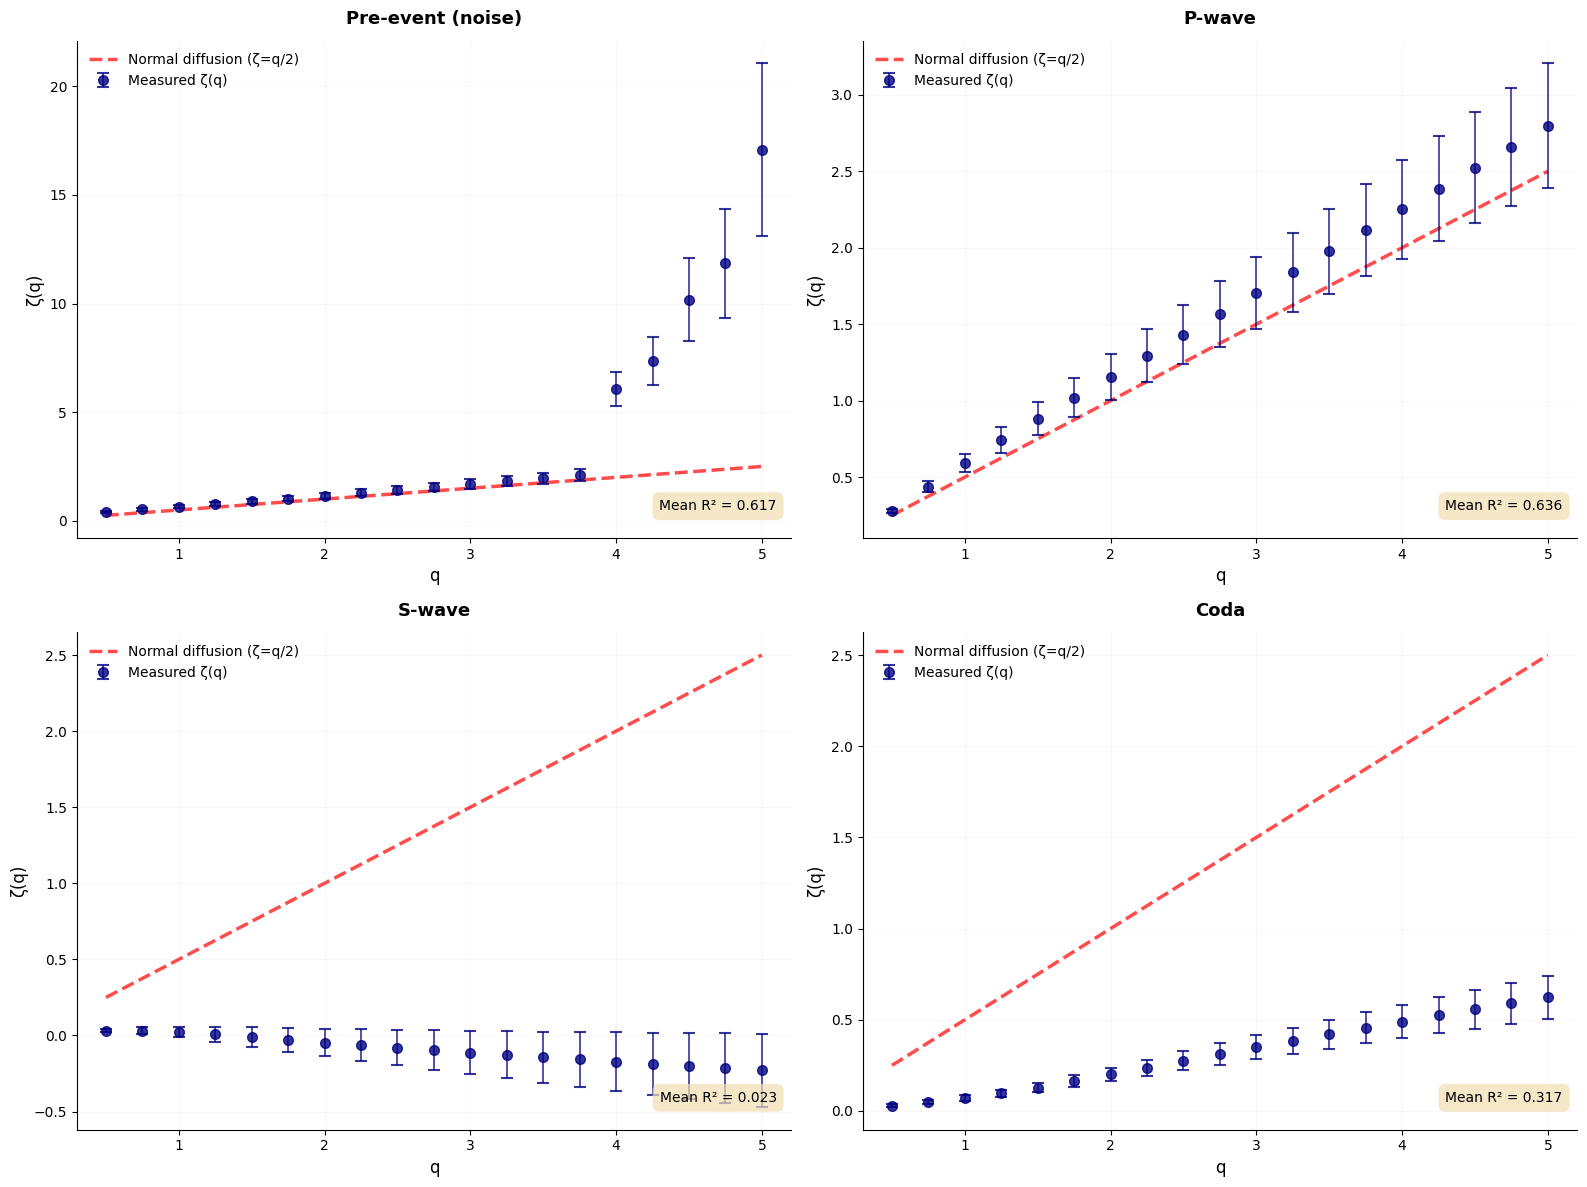

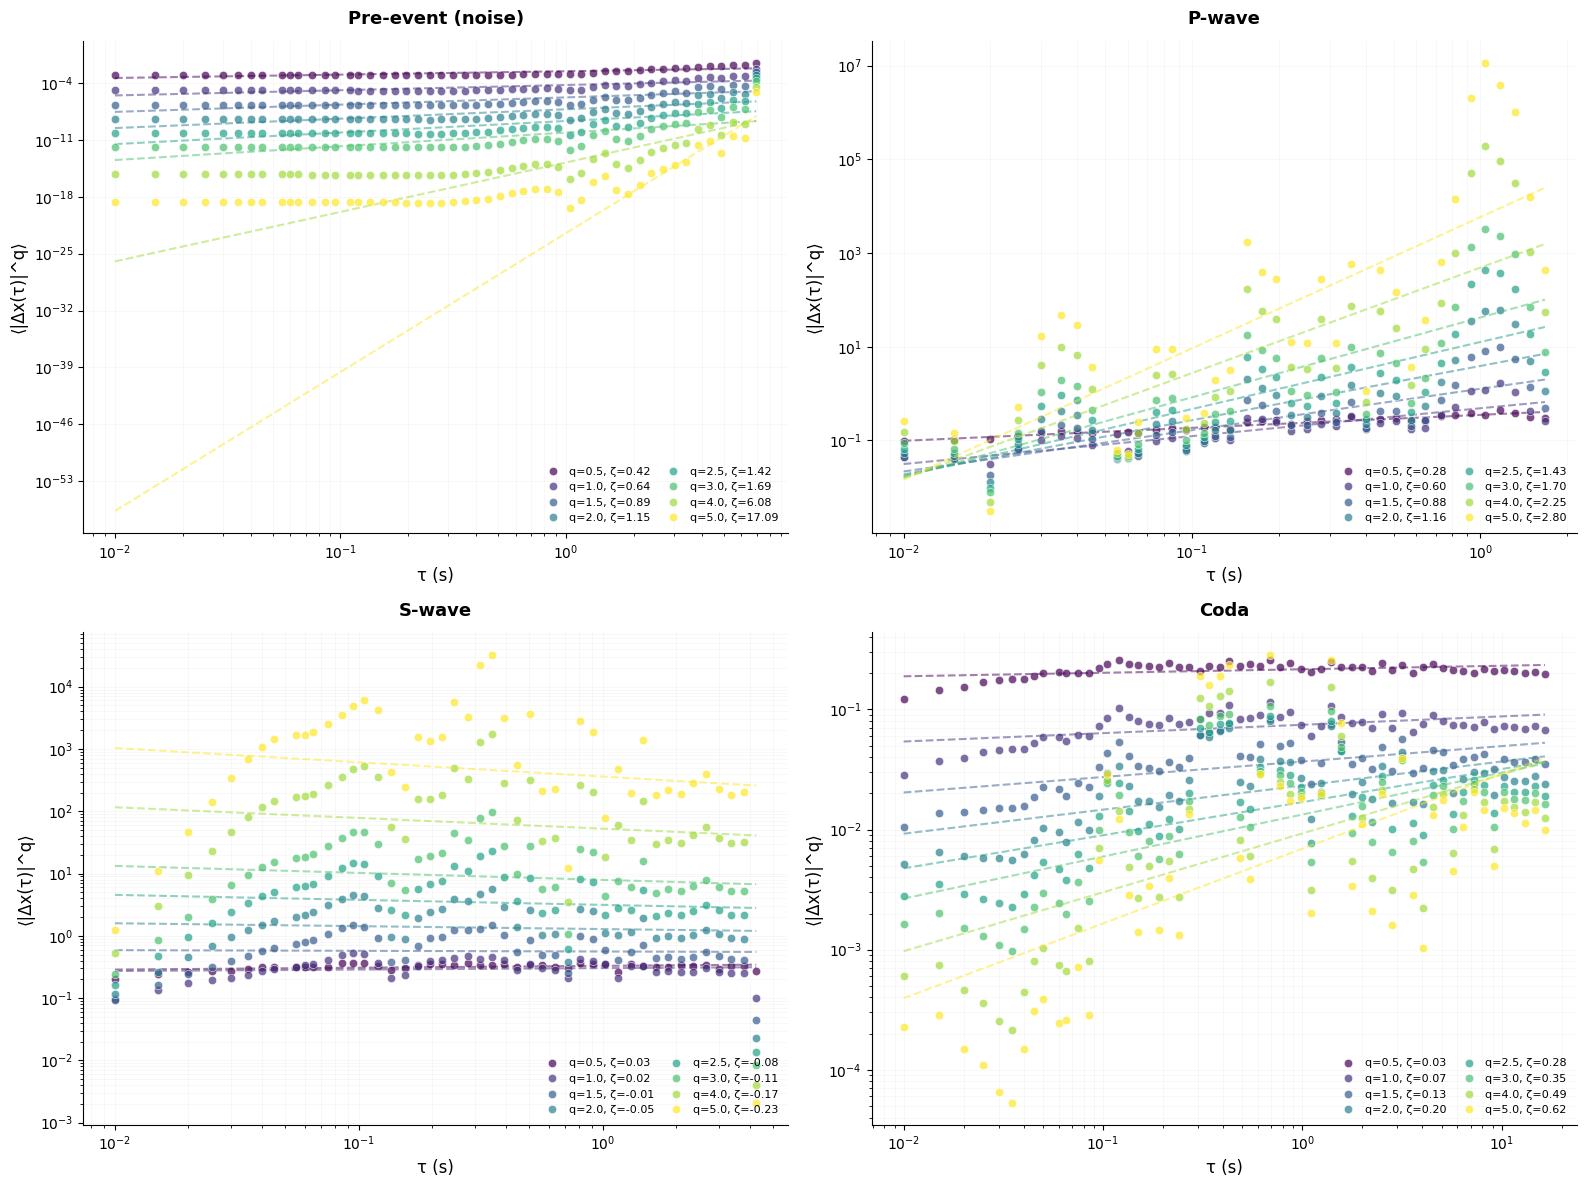

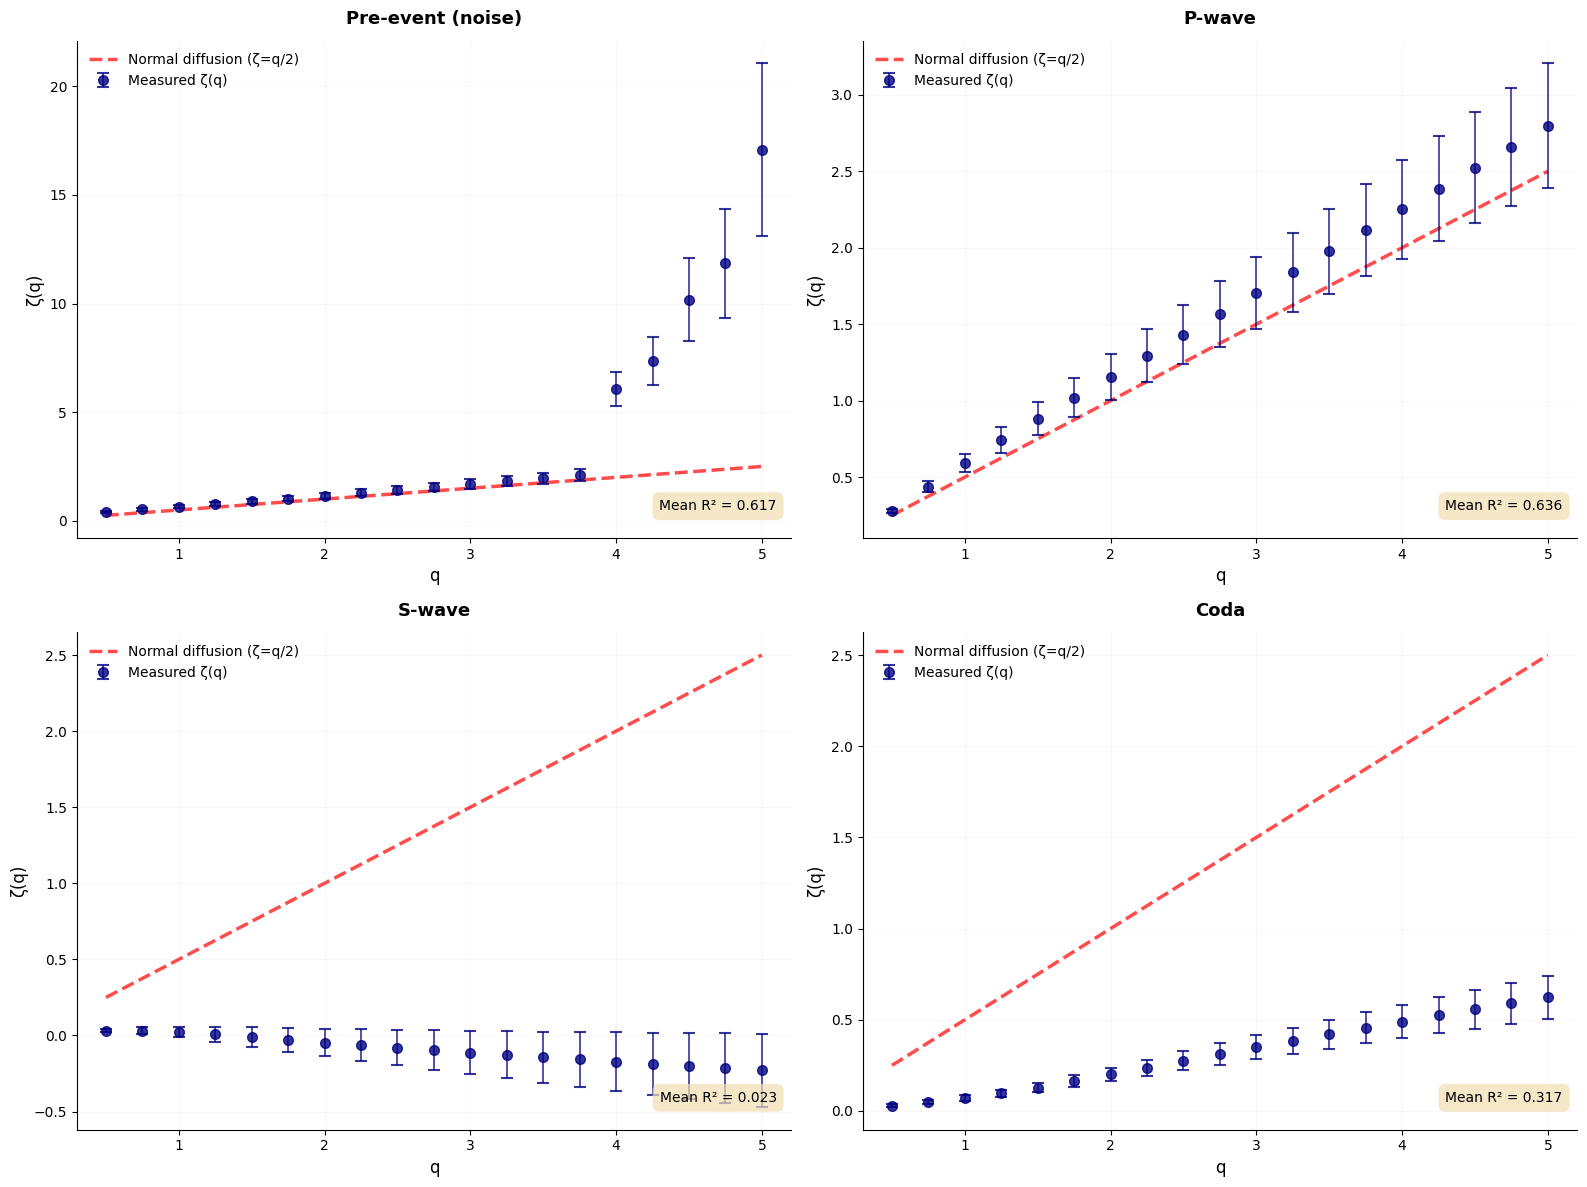

In [4]:
results = analyze_all_windows(
    windowed_signals_rautian,
    tau_min=0.01,
    n_tau=None,  # automatico
    q_values=q_values,
    sampling_rate=200.0,
    fit_range=None
)

# Save results
save_results_parquet(results, output_dir= SIGNALS_PROCESSED / '04b_moment_scaling' / 'acceleration' / 'rautian')

# Plot
plot_scaling_curves(results, output_dir= FIGURES_DIR / 'acceleration' / 'rautian')
plot_scaling_exponents(results, output_dir= FIGURES_DIR / 'acceleration' / 'rautian')

ENSEMBLE SPATIAL SCALING ANALYSIS
tau_min: 0.010 s (fixed for all windows)
q_values: 19 values from 0.50 to 5.00
sampling_rate: 200.0 Hz

Processing window: PRE_EVENT
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 6.9750] s
Number of tau points: 50
Mean ζ(q): 3.6737 ± 4.5657
Mean R²: 0.6173
ζ(q=1): 0.6412
ζ(q=2): 1.1541

Processing window: P_WAVE
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 1.6750] s
Number of tau points: 38
Mean ζ(q): 1.5609 ± 0.7582
Mean R²: 0.6359
ζ(q=1): 0.5950
ζ(q=2): 1.1573

Processing window: S_WAVE
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 1.0000] s
Number of tau points: 34
Mean ζ(q): 0.1833 ± 0.0568
Mean R²: 0.0543
ζ(q=1): 0.1153
ζ(q=2): 0.1602

Processing window: CODA
-------------------------------------------------

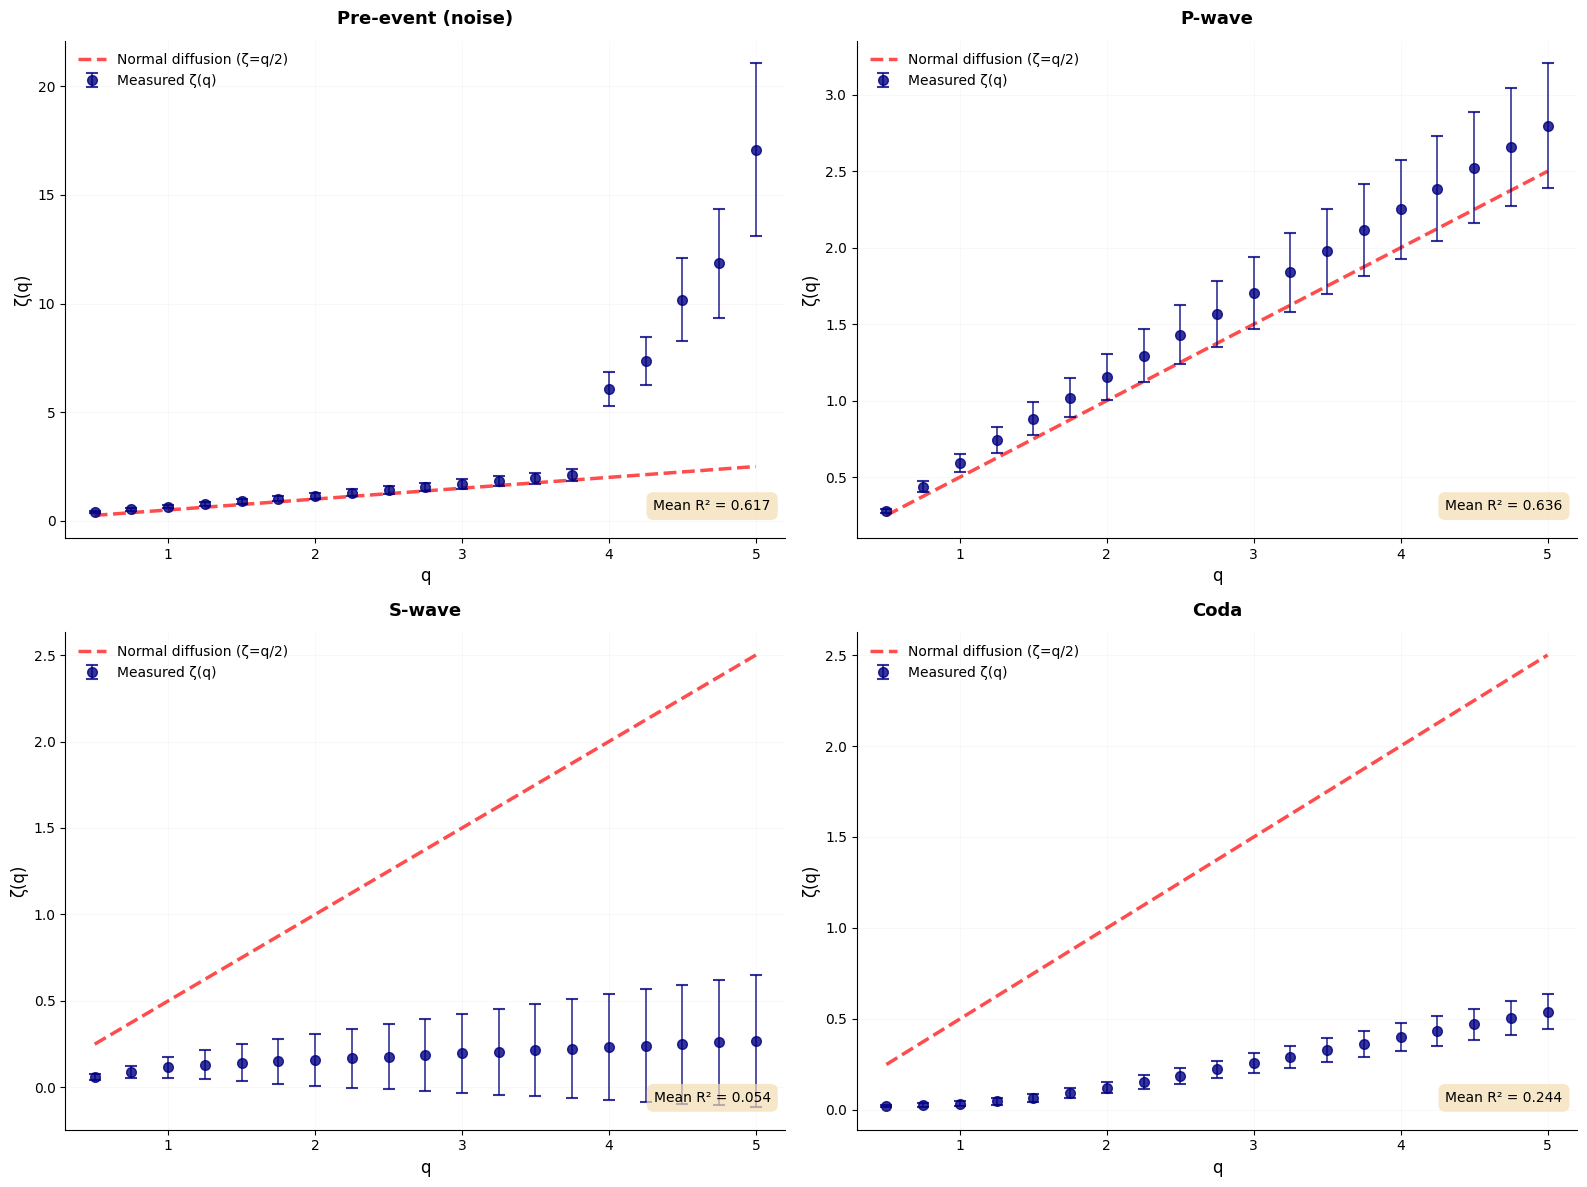

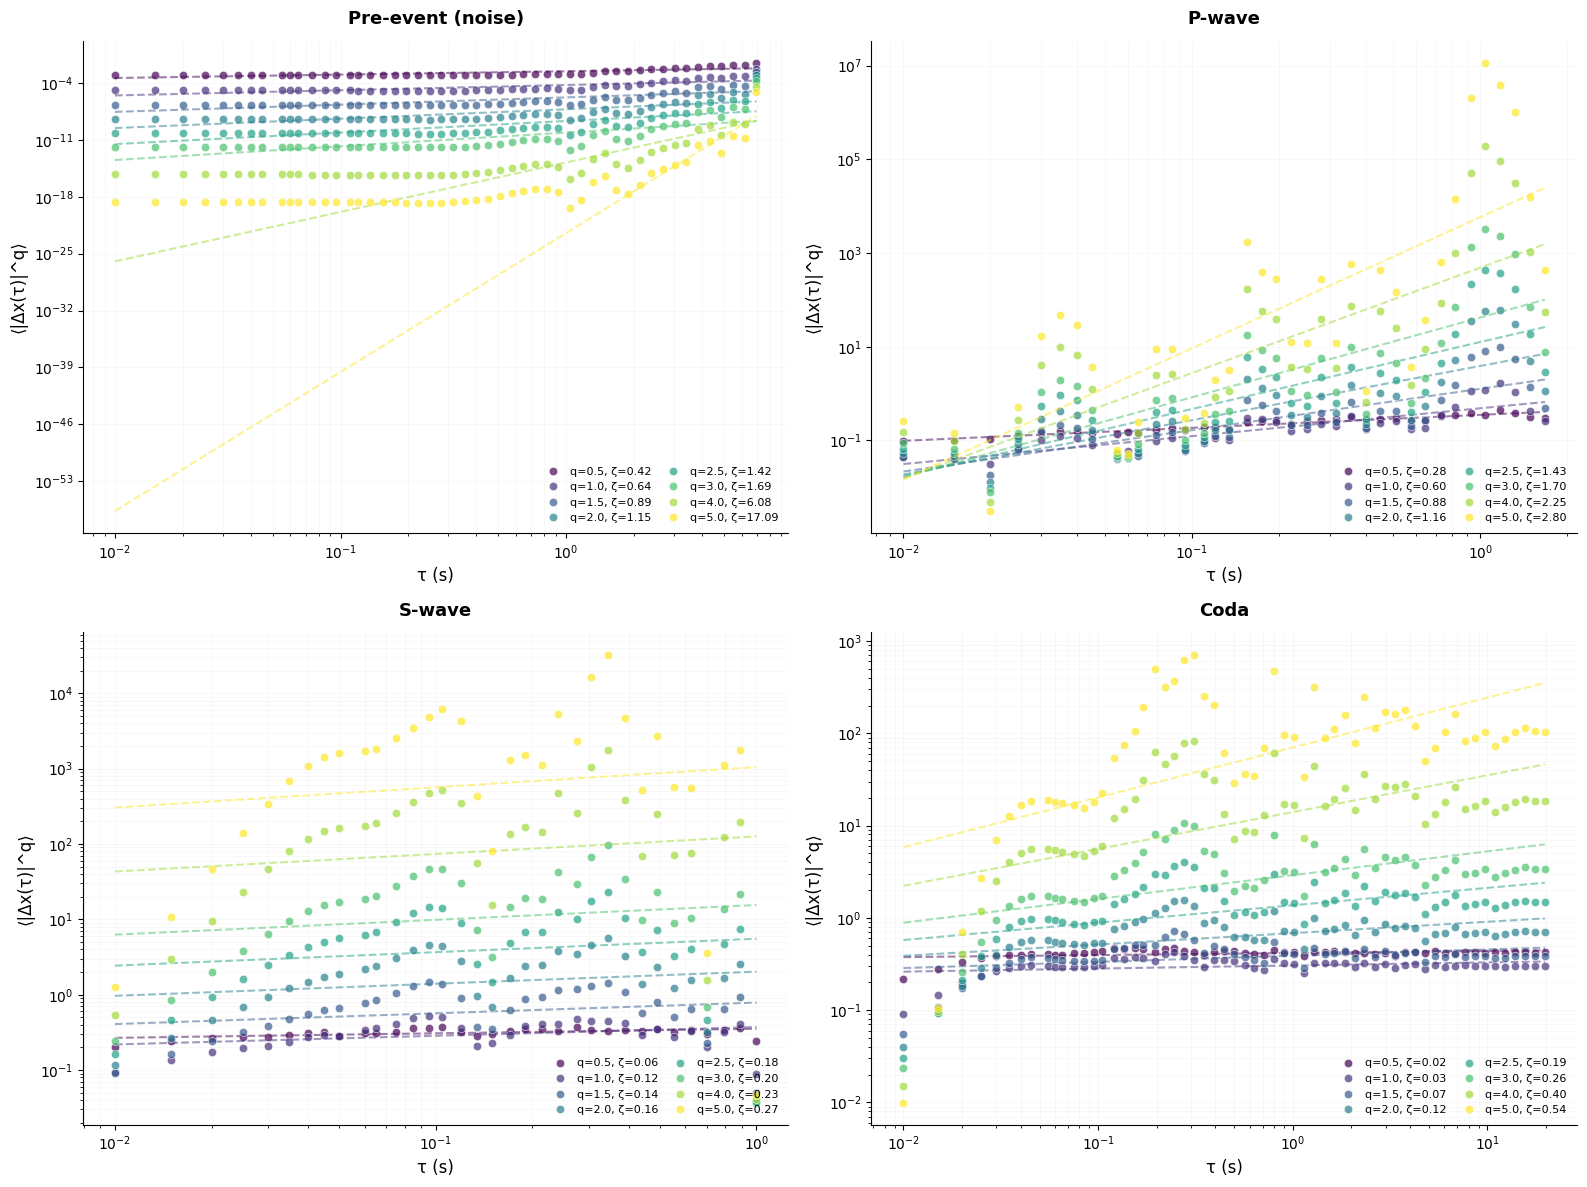

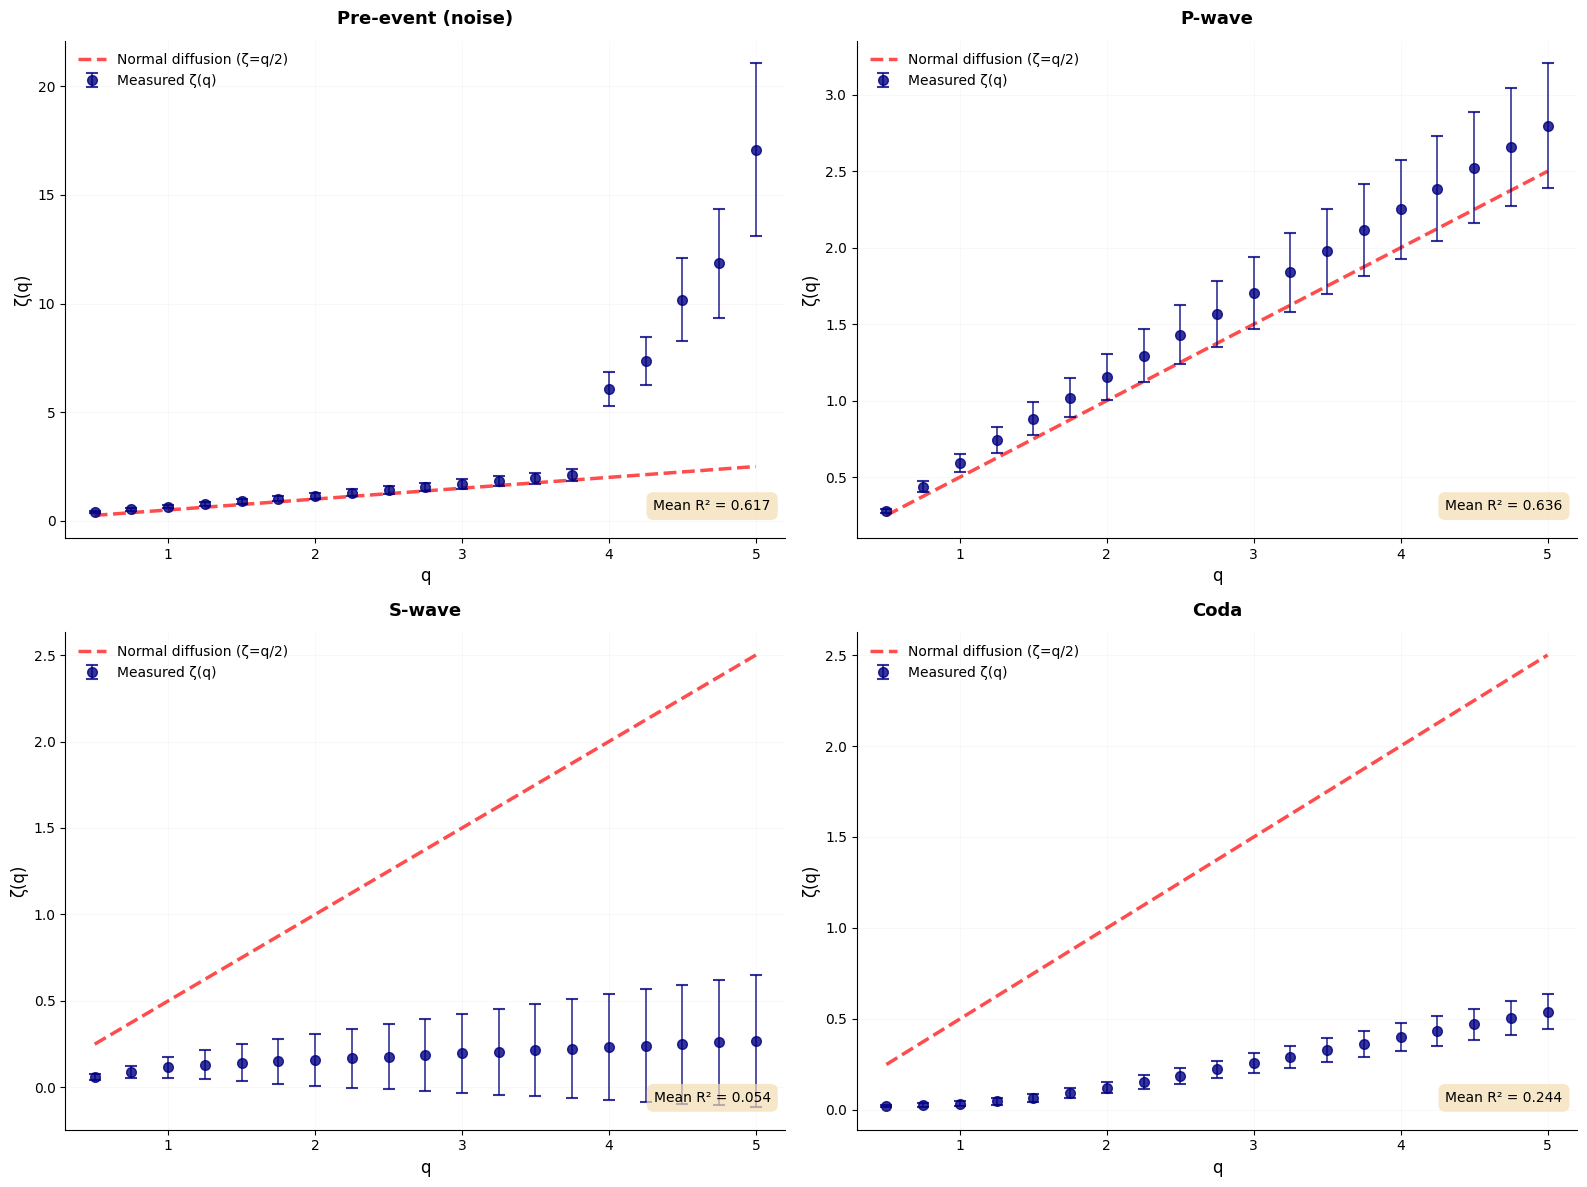

In [5]:
results = analyze_all_windows(
    windowed_signals_arias,
    tau_min=0.01,
    n_tau=None,  # automatico
    q_values=q_values,
    sampling_rate=200.0,
    fit_range=None
)

# Save results
save_results_parquet(results, output_dir= SIGNALS_PROCESSED / '04b_moment_scaling' / 'acceleration' / 'arias')

# Plot
plot_scaling_curves(results, output_dir= FIGURES_DIR / 'acceleration' / 'arias')
plot_scaling_exponents(results, output_dir= FIGURES_DIR / 'acceleration' / 'arias')

ENSEMBLE SPATIAL SCALING ANALYSIS
tau_min: 0.010 s (fixed for all windows)
q_values: 19 values from 0.50 to 5.00
sampling_rate: 200.0 Hz

Processing window: PRE_EVENT
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 6.9750] s
Number of tau points: 50
Mean ζ(q): 3.6737 ± 4.5657
Mean R²: 0.6173
ζ(q=1): 0.6412
ζ(q=2): 1.1541

Processing window: P_WAVE
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 1.6750] s
Number of tau points: 38
Mean ζ(q): 1.5609 ± 0.7582
Mean R²: 0.6359
ζ(q=1): 0.5950
ζ(q=2): 1.1573

Processing window: S_WAVE
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 1.0000] s
Number of tau points: 34
Mean ζ(q): 0.3671 ± 0.1578
Mean R²: 0.1905
ζ(q=1): 0.1617
ζ(q=2): 0.2959

Processing window: CODA
-------------------------------------------------

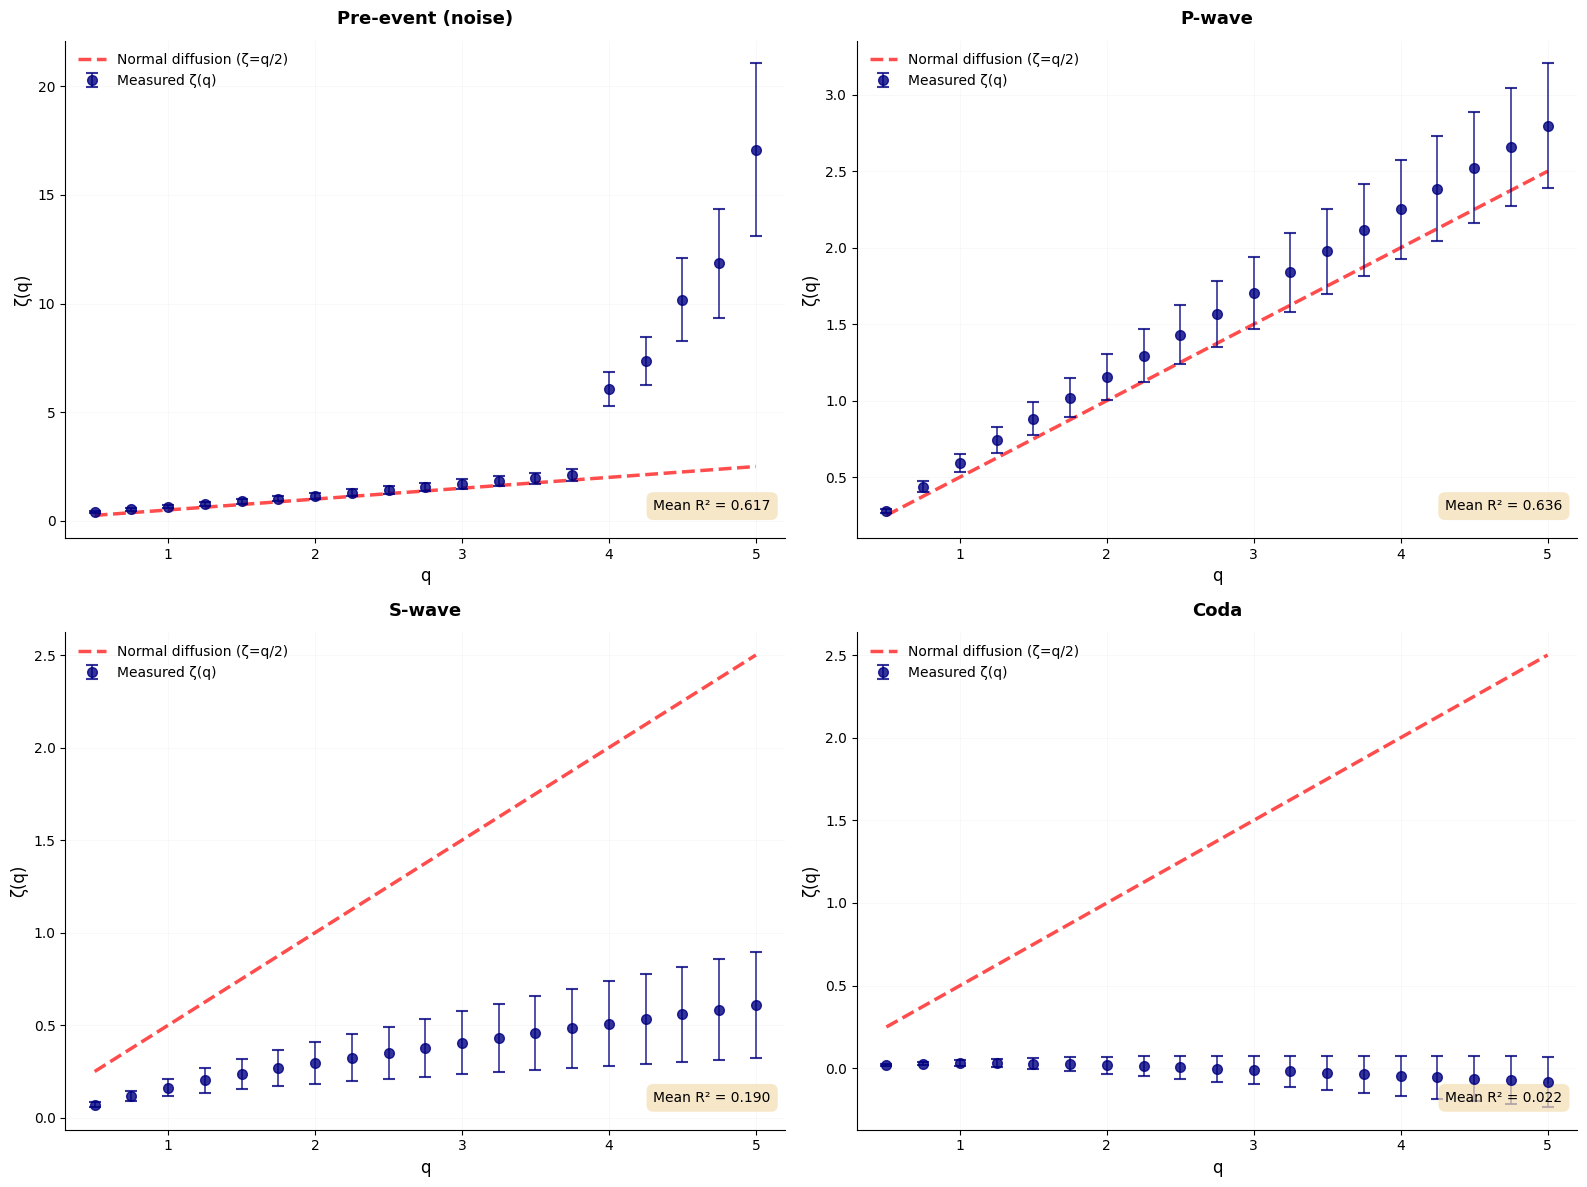

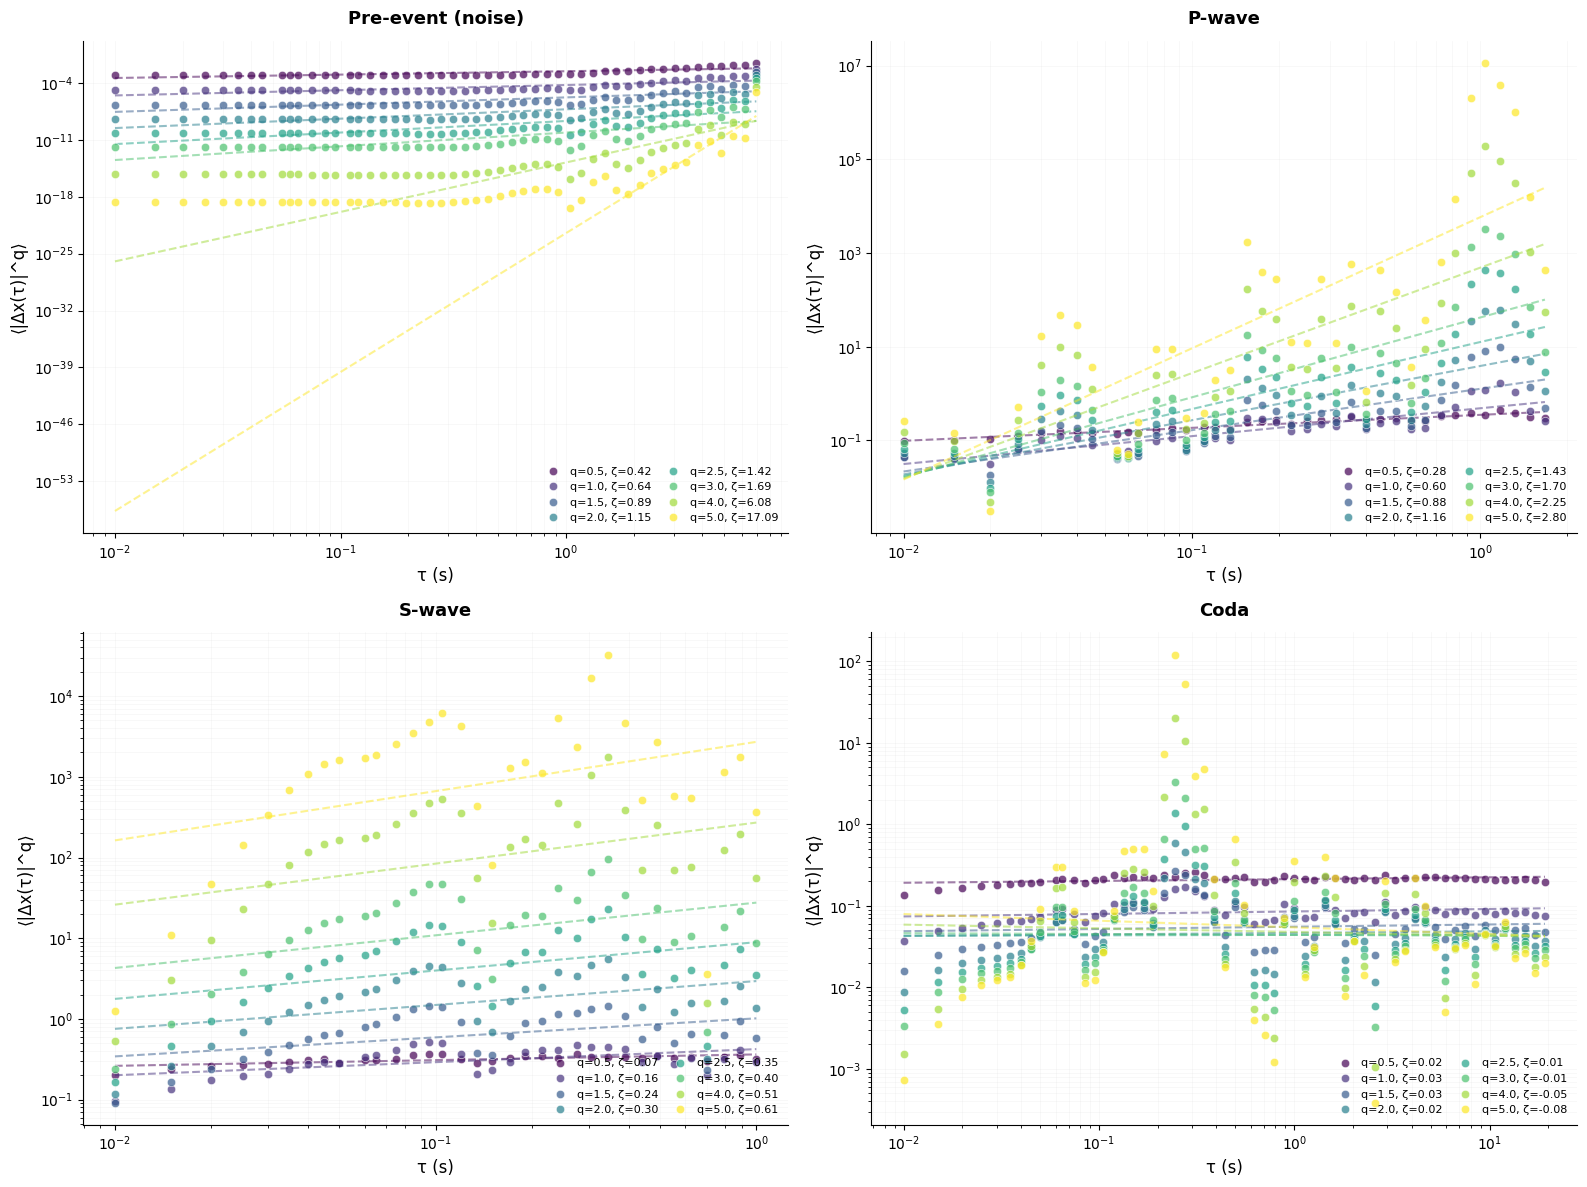

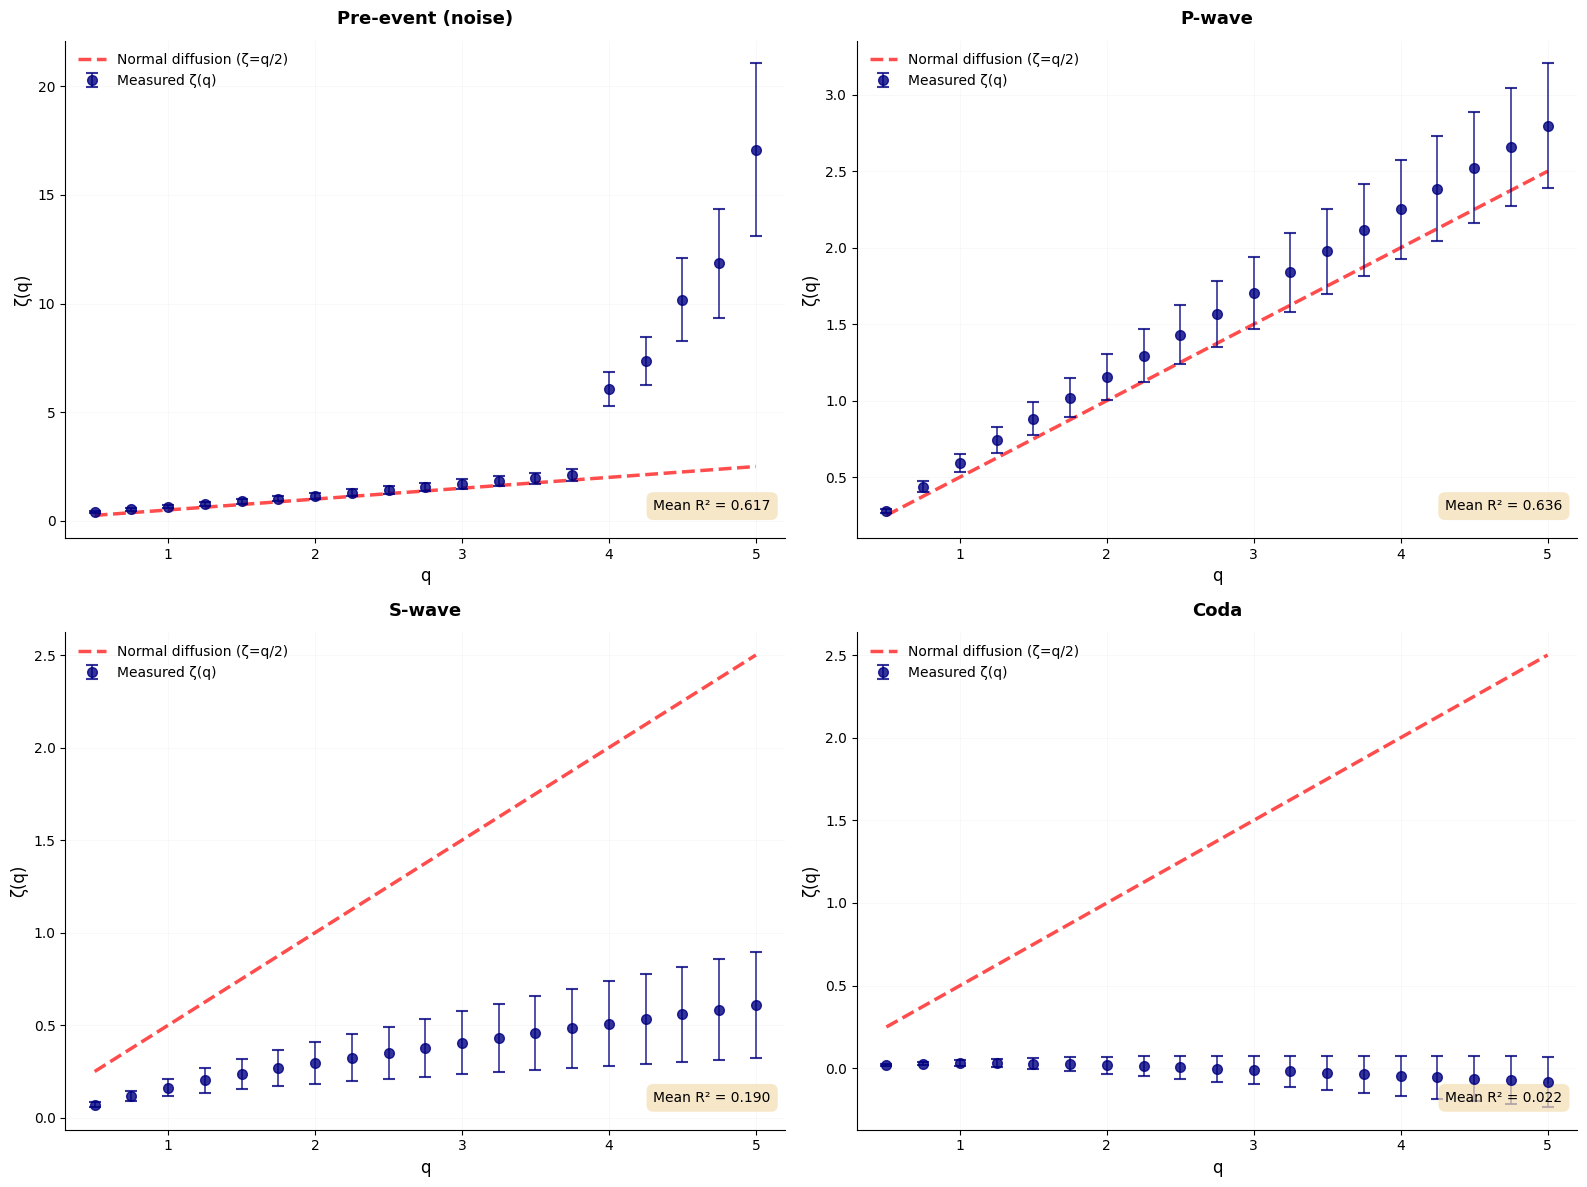

In [6]:
results = analyze_all_windows(
    windowed_signals_envelope,
    tau_min=0.01,
    n_tau=None,  # automatico
    q_values=q_values,
    sampling_rate=200.0,
    fit_range=None
)

# Save results
save_results_parquet(results, output_dir= SIGNALS_PROCESSED / '04b_moment_scaling' / 'acceleration' / 'envelope')

# Plot
plot_scaling_curves(results, output_dir= FIGURES_DIR / 'acceleration' / 'envelope')
plot_scaling_exponents(results, output_dir= FIGURES_DIR / 'acceleration' / 'envelope')

## 7. Results overview

Display scaling exponents ζ(q) for each window and process.

## 8. Visualization

### 8.1 Displacement: ζ(q) across windows

Compare scaling exponents for the four temporal windows.

**Expected behavior**:
- Pre-arrival: ζ(q) ≈ 0 (no scaling, noise)
- P-wave: ζ(q) > 0, linear with slope a
- S-wave: ζ(q) > 0, linear with slope b ≠ a (different regime)
- Coda: ζ(q) ≈ 0 (return to noise)

### 8.2 Displacement: Moments M_q(τ) for P-wave

Verify power-law scaling: $M_q(\tau) \sim \tau^{\zeta(q)}$

### 8.3 All processes: ζ(q) comparison for S-wave

Compare scaling behavior across acceleration, velocity, and displacement for S-wave window.

## 9. Summary

Create summary DataFrame with key results for each window and process.